Dataset loaded successfully


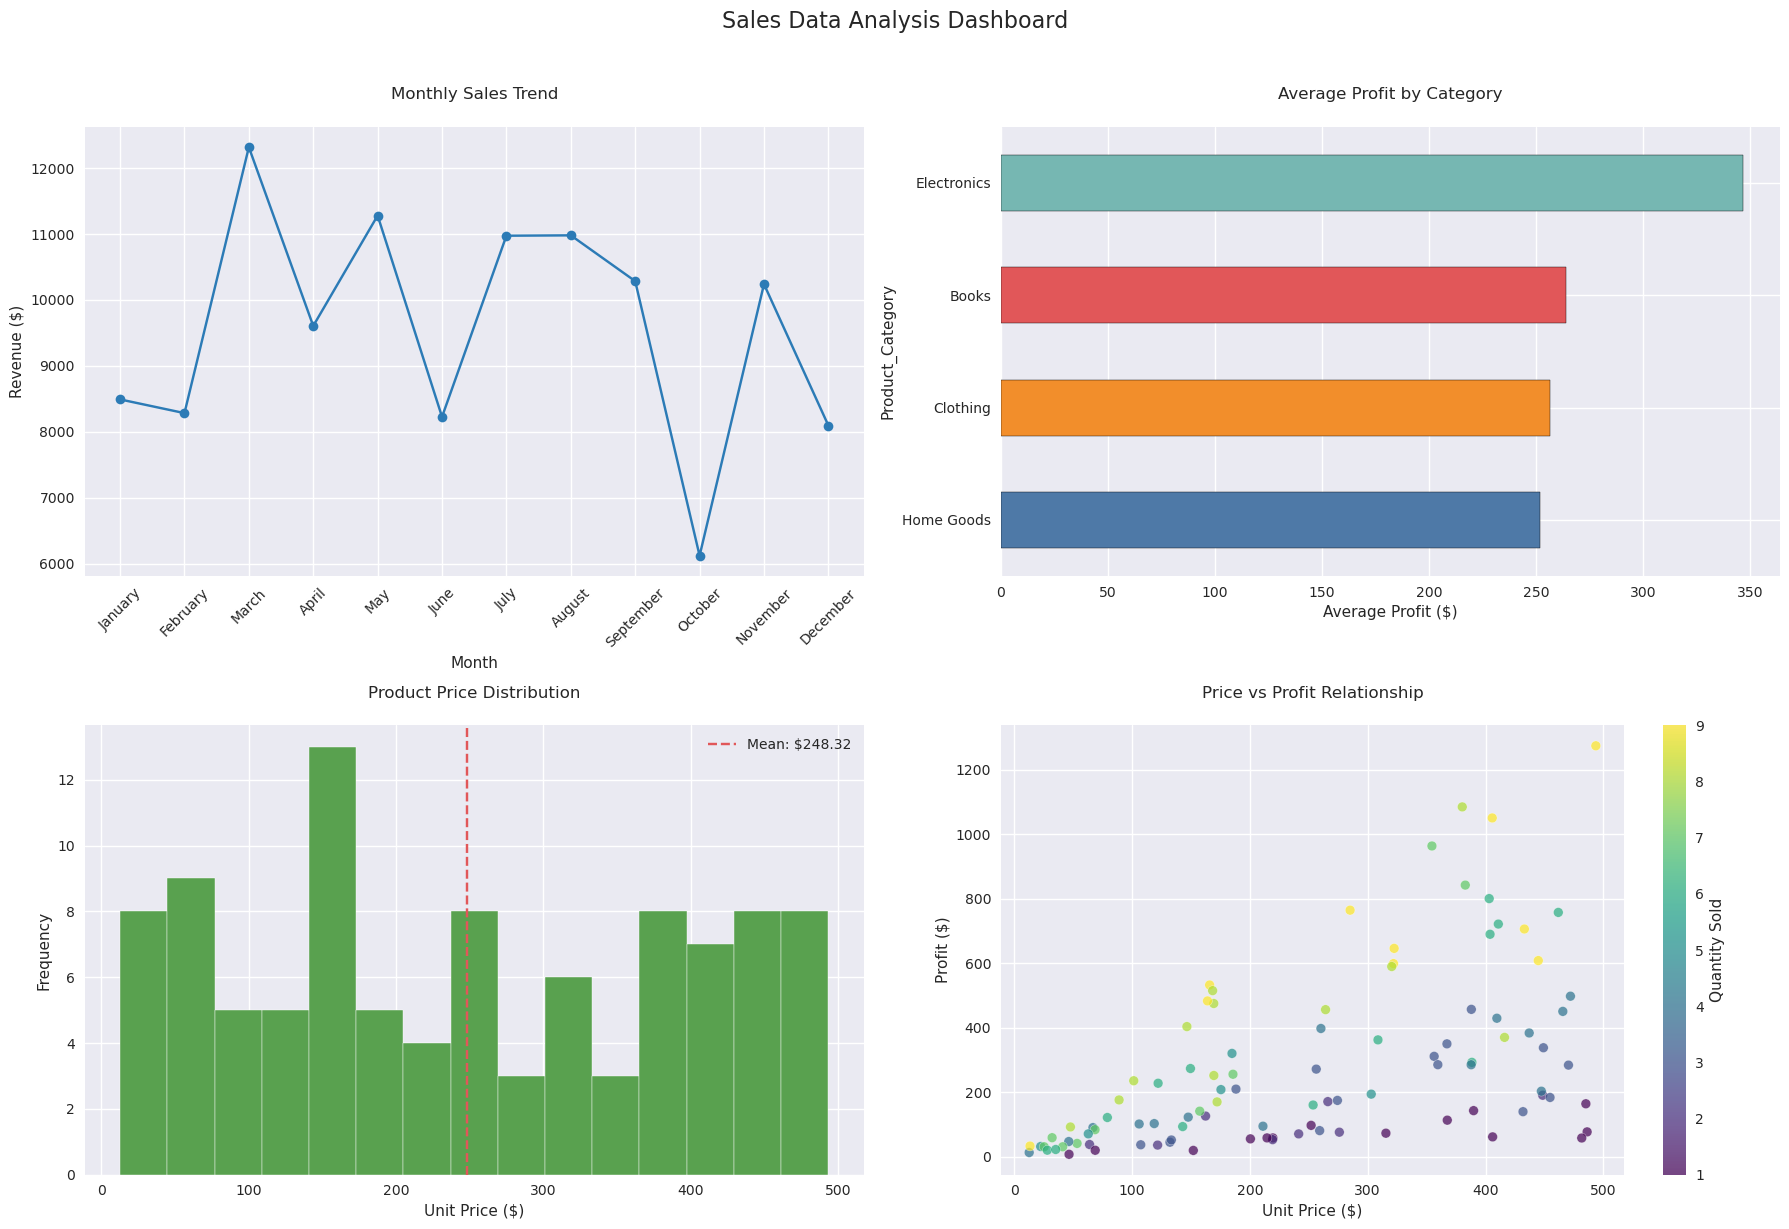

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Data Preparation ---
def load_sales_data():
    """Load or create sales data with guaranteed DataFrame return"""
    try:
        df = pd.read_csv("sales_data.csv")
        print("Dataset loaded successfully")
    except FileNotFoundError:
        print("Creating sample dataset...")
        np.random.seed(42)
        
        data = {
            'Order_Date': pd.date_range(start='2023-01-01', periods=100, freq='D'),
            'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home Goods', 'Books'], 100),
            'Unit_Price': np.round(np.random.uniform(10, 500, 100), 2),
            'Quantity': np.random.randint(1, 10, 100),
            'Region': np.random.choice(['West', 'East', 'North', 'South'], 100)
        }
        
        data['Revenue'] = data['Unit_Price'] * data['Quantity']
        data['Profit'] = data['Revenue'] * np.random.uniform(0.1, 0.4, 100)
        
        df = pd.DataFrame(data).round(2)
        df.to_csv("sales_data.csv", index=False)
        print("Sample dataset created")
    
    # Ensure proper date formatting
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])
    return df

# Load data
df = load_sales_data()

# --- Visualizations ---
plt.style.use('seaborn-v0_8')  # Updated style syntax

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Sales Data Analysis Dashboard', y=1.02, fontsize=16)

# 1. Line Chart: Monthly Sales Trend
ax1 = plt.subplot(2, 2, 1)
monthly_sales = df.resample('M', on='Order_Date')['Revenue'].sum()
ax1.plot(monthly_sales.index.month_name(), monthly_sales, marker='o', color='#2c7bb6')
ax1.set_title('Monthly Sales Trend', pad=20)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)')
plt.xticks(rotation=45)

#2. Bar Chart: Average Profit by Category
ax2 = plt.subplot(2, 2, 2)
category_profit = df.groupby('Product_Category')['Profit'].mean().sort_values()
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
category_profit.plot(kind='barh', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Average Profit by Category', pad=20)
ax2.set_xlabel('Average Profit ($)')

# 3. Histogram: Unit Price Distribution
ax3 = plt.subplot(2, 2, 3)
ax3.hist(df['Unit_Price'], bins=15, color='#59a14f', edgecolor='white')
ax3.set_title('Product Price Distribution', pad=20)
ax3.set_xlabel('Unit Price ($)')
ax3.set_ylabel('Frequency')
ax3.axvline(df['Unit_Price'].mean(), color='#e15759', linestyle='--', 
           label=f'Mean: ${df["Unit_Price"].mean():.2f}')
ax3.legend()

# 4. Scatter Plot: Price vs Profit
ax4 = plt.subplot(2, 2, 4)
scatter = ax4.scatter(df['Unit_Price'], df['Profit'], c=df['Quantity'], 
                     cmap='viridis', alpha=0.7, edgecolors='w')
ax4.set_title('Price vs Profit Relationship', pad=20)
ax4.set_xlabel('Unit Price ($)')
ax4.set_ylabel('Profit ($)')
fig.colorbar(scatter, ax=ax4, label='Quantity Sold')

plt.tight_layout()
plt.show()